# FarmTech Solutions — Fase 5
## Previsão de Rendimento de Safra e Descoberta de Tendências de Produtividade

**PBL de Inteligência Artificial — FIAP | Cap 01, Fase 5**

| Integrante | RM |
|---|---|
| Kainan Bilibio Aguiar | 570594 |
| Guilherme C. Ávila | 571294 |

---

### Contexto

A FarmTech Solutions presta serviços de Inteligência Artificial a uma fazenda de
médio porte — **200 hectares**, aproximadamente 210 campos de futebol oficiais —
que cultiva várias culturas simultaneamente.

A fazenda coleta, por meio de sensores em campo, quatro variáveis de solo e clima.
A pergunta de negócio é direta: **dadas as condições medidas, qual será o
rendimento da safra?** E, antes disso: **existe algum padrão recorrente que
agrupe as safras por comportamento produtivo?**

### Objetivo do notebook

1. **Análise exploratória** — entender a estrutura, a qualidade e o comportamento dos dados
2. **Aprendizado não supervisionado** — clusterizar para encontrar tendências de
   produtividade e identificar cenários discrepantes (*outliers*)
3. **Aprendizado supervisionado** — construir e comparar **cinco modelos de regressão**,
   cada um com um algoritmo diferente, avaliados por métricas pertinentes ao problema

### Sumário

- [0. Configuração do ambiente](#bloco0)
- [1. Análise Exploratória dos Dados](#bloco1)
- [2. Clusterização e detecção de outliers](#bloco2)
- [3. Modelagem preditiva — cinco algoritmos](#bloco3)
- [4. Conclusões, pontos fortes e limitações](#bloco4)


<a id="bloco0"></a>
## 0. Configuração do ambiente

Importações, semente aleatória fixa e padronização visual dos gráficos.

A semente (`RANDOM_STATE`) é fixada uma única vez e reutilizada em toda divisão
de dados e em todo algoritmo estocástico do notebook. Sem isso, cada execução
produziria métricas diferentes e a comparação entre os cinco modelos deixaria de
ser reprodutível.


In [1]:
# Manipulacao de dados
import pandas as pd
import numpy as np

# Visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# Semente unica para todo o notebook - garante reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Padronizacao visual: mesma paleta e grid em todos os graficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Exibe numeros com 2 casas decimais e sem notacao cientifica
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", None)

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 3.0.5 | numpy 2.5.2 | seaborn 0.13.2


In [2]:
# Caminho relativo a raiz do repositorio - o notebook e executado a partir dela
CAMINHO_DADOS = "dados/crop_yield.csv"

df_bruto = pd.read_csv(CAMINHO_DADOS)

print(f"Arquivo carregado: {CAMINHO_DADOS}")
print(f"Dimensoes: {df_bruto.shape[0]} observacoes x {df_bruto.shape[1]} colunas")

Arquivo carregado: dados/crop_yield.csv
Dimensoes: 156 observacoes x 6 colunas


<a id="bloco1"></a>
## 1. Análise Exploratória dos Dados

O objetivo desta seção é responder três perguntas antes de qualquer modelagem:
**o que há na base**, **a base tem qualidade suficiente** e **o que os dados já
revelam sozinhos**.

### 1.1 Estrutura e integridade


In [3]:
# Primeiras linhas - inspecao visual do formato bruto
df_bruto.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [4]:
# Tipos de dado e uso de memoria
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [5]:
# Contagem de valores ausentes e duplicados - diagnostico de qualidade
diagnostico = pd.DataFrame({
    "tipo": df_bruto.dtypes.astype(str),
    "nulos": df_bruto.isnull().sum(),
    "% nulos": (df_bruto.isnull().sum() / len(df_bruto) * 100).round(2),
    "valores unicos": df_bruto.nunique(),
})

print(f"Linhas duplicadas na base: {df_bruto.duplicated().sum()}")
diagnostico

Linhas duplicadas na base: 0


,tipo,nulos,% nulos,valores unicos
Crop,str,0,0.00,4
Precipitation (mm day-1),float64,0,0.00,39
Specific Humidity at 2 Meters (g/kg),float64,0,0.00,33
Relative Humidity at 2 Meters (%),float64,0,0.00,38
Temperature at 2 Meters (C),float64,0,0.00,29
Yield,int64,0,0.00,155


**Achado.** A base tem **156 observações** e **zero valores ausentes** em todas
as seis colunas — não há necessidade de imputação, remoção de linhas ou qualquer
tratamento de dados faltantes. Também não há linhas duplicadas.

Isso é incomum em dados reais de campo e sugere que a base já passou por um
processo de curadoria antes de ser disponibilizada. É um ponto positivo para a
modelagem, mas é também a primeira limitação a registrar: **um modelo treinado
em dados perfeitos não aprende a lidar com falha de sensor**, que é a realidade
de uma fazenda instrumentada.

### 1.2 Padronização dos nomes das colunas

Os cabeçalhos originais vêm em inglês, com unidade de medida embutida no nome e
com espaços e parênteses:

`Precipitation (mm day-1)`, `Specific Humidity at 2 Meters (g/kg)`, ...

Nomes assim são impraticáveis em fórmulas, em rótulos de gráfico e em qualquer
seleção por atributo. Renomeamos para identificadores curtos em português,
mantendo abaixo o dicionário de-para para rastreabilidade — a unidade não se
perde, apenas migra do nome da coluna para a documentação e para os eixos dos
gráficos.

> **Observação.** O enunciado do projeto descreve as variáveis em português.
> O arquivo entregue traz os cabeçalhos em inglês. O mapeamento abaixo torna
> essa correspondência explícita.


In [6]:
# Dicionario de-para: cabecalho original -> identificador curto
MAPA_COLUNAS = {
    "Crop":                                  "cultura",
    "Precipitation (mm day-1)":              "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)":  "umid_especifica",
    "Relative Humidity at 2 Meters (%)":     "umid_relativa",
    "Temperature at 2 Meters (C)":           "temperatura",
    "Yield":                                 "rendimento_bruto",
}

# Unidades preservadas para uso nos rotulos dos graficos
UNIDADES = {
    "precipitacao":    "mm/dia",
    "umid_especifica": "g/kg",
    "umid_relativa":   "%",
    "temperatura":     "°C",
}

df = df_bruto.rename(columns=MAPA_COLUNAS)

# Tabela de rastreabilidade do renomeio
pd.DataFrame(
    {"cabecalho original": list(MAPA_COLUNAS.keys()),
     "identificador": list(MAPA_COLUNAS.values())}
)

,cabecalho original,identificador
0,Crop,cultura
1,Precipitation (mm day-1),precipitacao
2,Specific Humidity at 2 Meters (g/kg),umid_especifica
3,Relative Humidity at 2 Meters (%),umid_relativa
4,Temperature at 2 Meters (C),temperatura
5,Yield,rendimento_bruto


### 1.3 A unidade da variável alvo: uma divergência que precisa ser tratada

O enunciado afirma que o rendimento está expresso em **toneladas por hectare**.
Os valores da coluna, porém, vão de **5.249 a 203.399**. Uma produtividade de
203 mil toneladas por hectare é fisicamente impossível — o recorde mundial de
qualquer cultura está na casa das dezenas de toneladas por hectare.

A hipótese é que a base siga a convenção da **FAOSTAT**, o banco de dados
agrícola da FAO/ONU, cuja unidade padrão de rendimento é o **hectograma por
hectare (hg/ha)**. Um hectograma é 0,1 kg, portanto:

$$\text{t/ha} = \frac{\text{hg/ha}}{10.000}$$

A célula seguinte testa essa hipótese contra valores de referência conhecidos
para cada cultura.


In [7]:
# Converte hg/ha (padrao FAOSTAT) para toneladas por hectare
df["rendimento"] = df["rendimento_bruto"] / 10_000

# Testa a hipotese: os valores convertidos sao agronomicamente plausiveis?
# Faixas de referencia mundiais (FAO) para validar a ordem de grandeza
REFERENCIA_TON_HA = {
    "Cocoa, beans":    "0,3 - 1,5",
    "Oil palm fruit":  "10 - 25",
    "Rice, paddy":     "3 - 7",
    "Rubber, natural": "0,5 - 1,5",
}

validacao = df.groupby("cultura").agg(
    bruto_min=("rendimento_bruto", "min"),
    bruto_max=("rendimento_bruto", "max"),
    convertido_min=("rendimento", "min"),
    convertido_max=("rendimento", "max"),
)
validacao["referencia FAO (t/ha)"] = validacao.index.map(REFERENCIA_TON_HA)
validacao

,bruto_min,bruto_max,convertido_min,convertido_max,referencia FAO (t/ha)
cultura,,,,,
"Cocoa, beans",5765,13056,0.58,1.31,"0,3 - 1,5"
Oil palm fruit,142425,203399,14.24,20.34,10 - 25
"Rice, paddy",24686,42550,2.47,4.25,3 - 7
"Rubber, natural",5249,10285,0.52,1.03,"0,5 - 1,5"


**Achado — a hipótese se confirma.** Após dividir por 10.000, os quatro
intervalos caem exatamente dentro das faixas de referência da FAO:

| Cultura | Convertido (t/ha) | Referência mundial |
|---|---|---|
| Cacau em amêndoas | 0,58 – 1,31 | 0,3 – 1,5 |
| Fruto de dendê | 14,24 – 20,34 | 10 – 25 |
| Arroz em casca | 2,47 – 4,25 | 3 – 7 |
| Borracha natural | 0,52 – 1,03 | 0,5 – 1,5 |

A coluna original está em **hg/ha**, não em t/ha como o enunciado descreve.

**Por que isso importa para a modelagem?** A divisão por uma constante não altera
o coeficiente de determinação ($R^2$) nem a ordem de classificação dos modelos —
é uma transformação linear. O que muda é a **interpretabilidade das métricas de
erro**: um MAE de 0,42 t/ha é uma informação acionável para o agrônomo da
fazenda; um MAE de 4.200 hg/ha não é. Seguimos com `rendimento` em t/ha como
variável alvo de todo o restante do trabalho.

### 1.4 Estatísticas descritivas


In [8]:
# Colunas numericas que serao usadas na analise e na modelagem
VARIAVEIS_CLIMA = ["precipitacao", "umid_especifica", "umid_relativa", "temperatura"]
ALVO = "rendimento"

df[VARIAVEIS_CLIMA + [ALVO]].describe().T

,count,mean,std,min,25%,50%,75%,max
precipitacao,156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
umid_especifica,156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
umid_relativa,156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
temperatura,156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
rendimento,156.00,5.62,7.04,0.52,0.83,1.89,6.75,20.34


In [9]:
# Distribuicao das observacoes entre as culturas
contagem = df["cultura"].value_counts().rename("observacoes").to_frame()
contagem["% do total"] = (contagem["observacoes"] / len(df) * 100).round(1)
contagem

,observacoes,% do total
cultura,,
"Cocoa, beans",39,25.00
Oil palm fruit,39,25.00
"Rice, paddy",39,25.00
"Rubber, natural",39,25.00


**Achado.** A base é **perfeitamente balanceada**: quatro culturas com exatamente
**39 observações cada**. Um número tão redondo e idêntico não ocorre por acaso em
coleta de campo — indica uma série histórica anual, provavelmente 39 anos de
registro por cultura. O arquivo, no entanto, **não traz a coluna de ano**, o que
nos impede de modelar tendência temporal ou identificar anos de evento climático
extremo. Registramos isso como limitação na seção final.

O balanceamento é uma boa notícia para a modelagem: nenhuma cultura está
sub-representada, e o modelo não terá viés de frequência.

### 1.5 Distribuição das variáveis


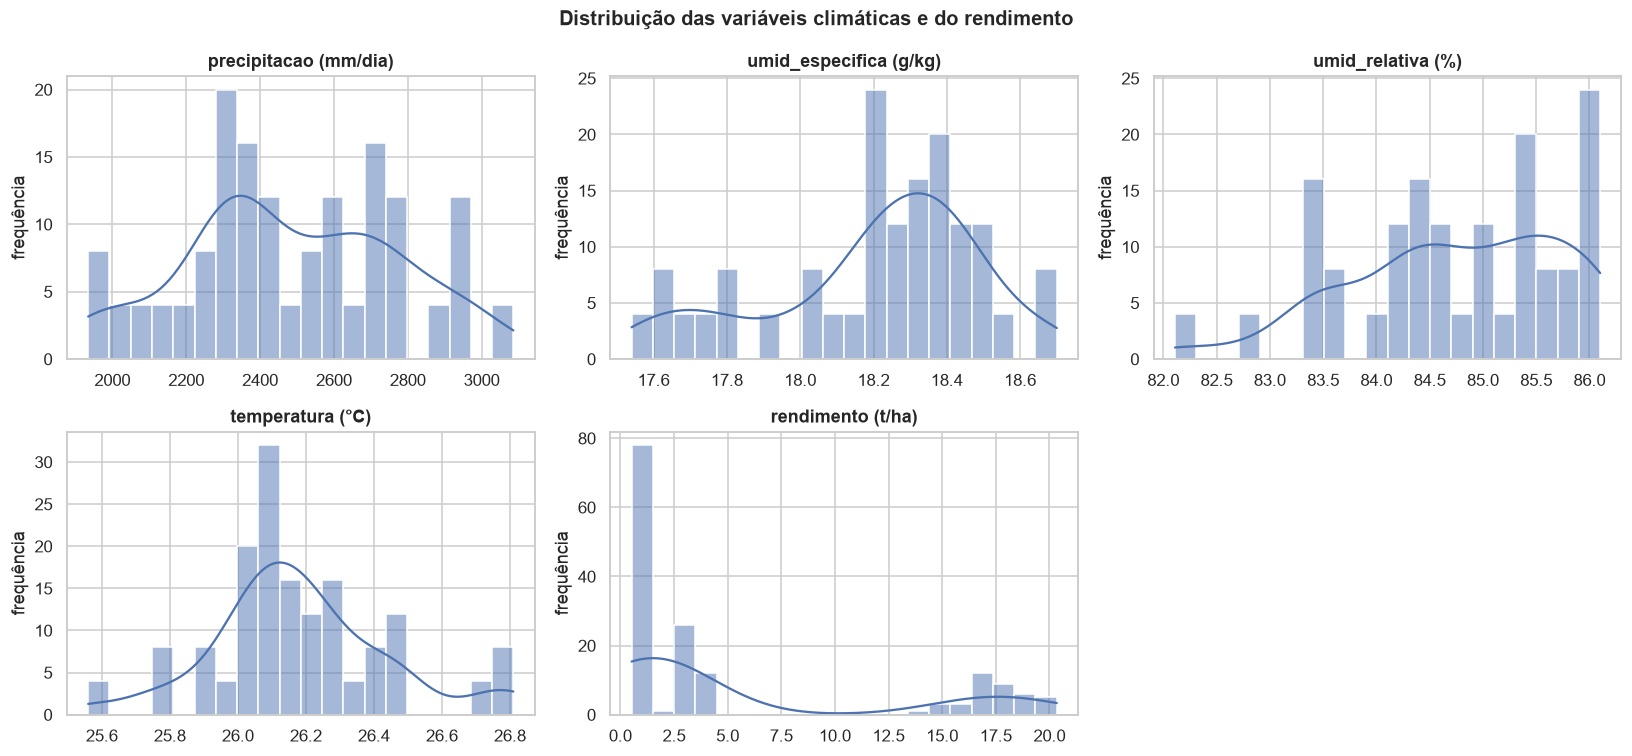

In [10]:
# Histograma com curva de densidade para cada variavel climatica e para o alvo
colunas_plot = VARIAVEIS_CLIMA + [ALVO]
fig, eixos = plt.subplots(2, 3, figsize=(15, 7))

for ax, coluna in zip(eixos.ravel(), colunas_plot):
    sns.histplot(data=df, x=coluna, kde=True, ax=ax, bins=20, edgecolor="white")
    unidade = UNIDADES.get(coluna, "t/ha")
    ax.set_title(f"{coluna} ({unidade})")
    ax.set_xlabel("")
    ax.set_ylabel("frequência")

# Remove o sexto subplot, que fica sem uso (5 variaveis em grade 2x3)
eixos.ravel()[-1].axis("off")
fig.suptitle("Distribuição das variáveis climáticas e do rendimento",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Achado.** O rendimento é a única variável com distribuição **fortemente
multimodal** — há picos separados por vazios, e não uma curva contínua. As
variáveis climáticas, por outro lado, são razoavelmente unimodais.

Essa multimodalidade não é ruído: é a assinatura das quatro culturas convivendo
na mesma coluna, cada uma com sua faixa própria de produtividade. A célula
seguinte torna isso explícito.

### 1.6 Rendimento por cultura — a escala que domina a base


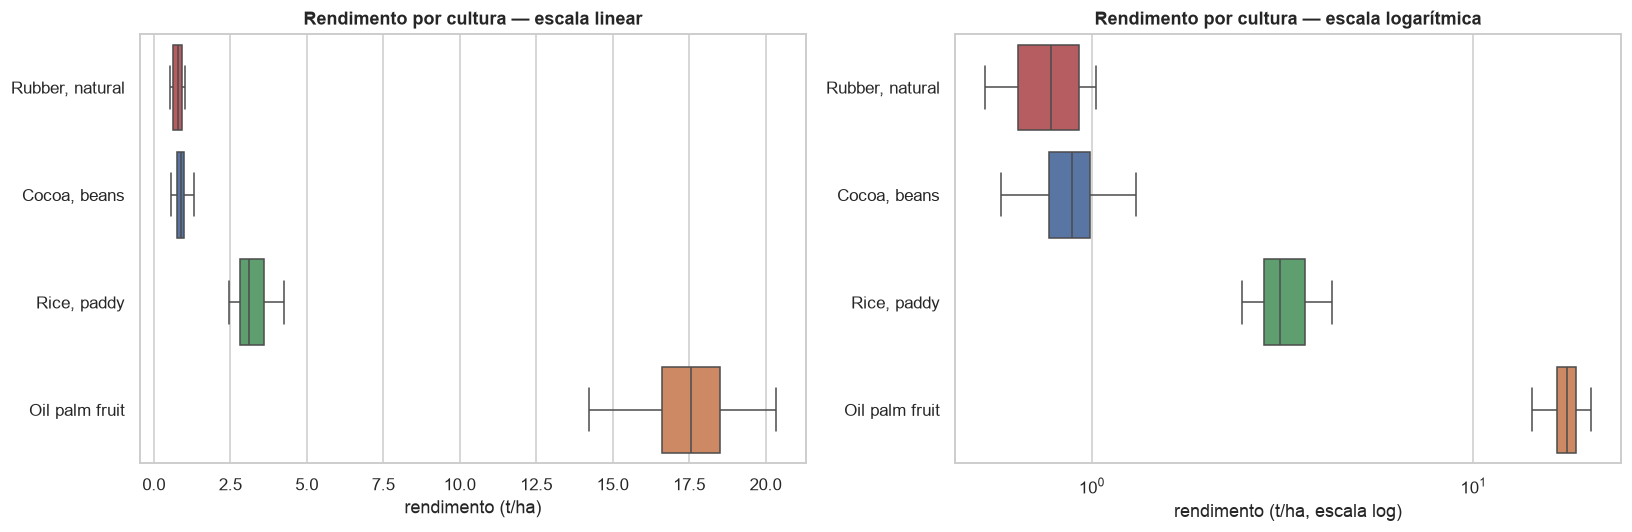

Cultura menos produtiva: Rubber, natural (0.78 t/ha)
Cultura mais produtiva:  Oil palm fruit (17.56 t/ha)
Razao entre elas: 22.5x


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Escala linear: revela a disparidade entre as culturas
ordem = df.groupby("cultura")[ALVO].median().sort_values().index
sns.boxplot(data=df, x=ALVO, y="cultura", order=ordem, ax=ax1, hue="cultura",
            legend=False)
ax1.set_title("Rendimento por cultura — escala linear")
ax1.set_xlabel("rendimento (t/ha)")
ax1.set_ylabel("")

# Escala logaritmica: permite comparar a dispersao interna de cada cultura
sns.boxplot(data=df, x=ALVO, y="cultura", order=ordem, ax=ax2, hue="cultura",
            legend=False)
ax2.set_xscale("log")
ax2.set_title("Rendimento por cultura — escala logarítmica")
ax2.set_xlabel("rendimento (t/ha, escala log)")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

# Quantifica a disparidade entre a cultura mais e a menos produtiva
medianas = df.groupby("cultura")[ALVO].median().sort_values()
razao = medianas.iloc[-1] / medianas.iloc[0]
print(f"Cultura menos produtiva: {medianas.index[0]} ({medianas.iloc[0]:.2f} t/ha)")
print(f"Cultura mais produtiva:  {medianas.index[-1]} ({medianas.iloc[-1]:.2f} t/ha)")
print(f"Razao entre elas: {razao:.1f}x")

**Achado central da exploração.** O dendê produz, na mediana, **22,5 vezes** mais
toneladas por hectare que a borracha natural. As faixas de rendimento das quatro
culturas são praticamente **disjuntas** — o gráfico da esquerda mostra os boxes
sem sobreposição.

Isso tem duas consequências diretas, que orientam todo o restante do notebook:

1. **Para a clusterização (seção 2):** qualquer algoritmo baseado em distância
   aplicado ao rendimento sem padronização vai separar as culturas, não os
   comportamentos produtivos. A padronização deixa de ser boa prática e passa a
   ser requisito.
2. **Para a correlação (seção 1.7):** uma correlação calculada sobre a base
   inteira vai medir a diferença **entre culturas**, e não o efeito do clima
   sobre a produtividade. É exatamente o que a próxima seção investiga.

### 1.7 Correlação: o que a análise global esconde


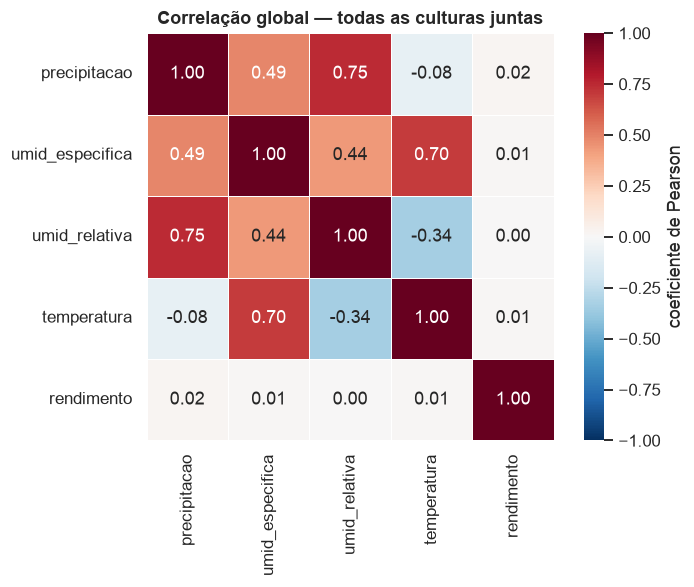

In [12]:
# Matriz de correlacao sobre a base inteira, ignorando a cultura
matriz_global = df[VARIAVEIS_CLIMA + [ALVO]].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(matriz_global, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "coeficiente de Pearson"})
plt.title("Correlação global — todas as culturas juntas")
plt.tight_layout()
plt.show()

In [13]:
# Correlacao de cada variavel climatica com o rendimento, calculada
# DENTRO de cada cultura - isola o efeito do clima do efeito da especie
correlacoes = {"GLOBAL (todas juntas)": matriz_global.loc[VARIAVEIS_CLIMA, ALVO]}

for cultura, grupo in df.groupby("cultura"):
    correlacoes[cultura] = grupo[VARIAVEIS_CLIMA + [ALVO]].corr().loc[VARIAVEIS_CLIMA, ALVO]

comparativo = pd.DataFrame(correlacoes).round(3)
comparativo.index.name = "variavel climatica"
comparativo

,GLOBAL (todas juntas),"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
variavel climatica,,,,,
precipitacao,0.02,0.17,0.22,0.33,0.10
umid_especifica,0.01,-0.06,0.07,0.70,-0.43
umid_relativa,0.00,-0.06,-0.04,0.15,-0.05
temperatura,0.01,-0.01,0.10,0.61,-0.41


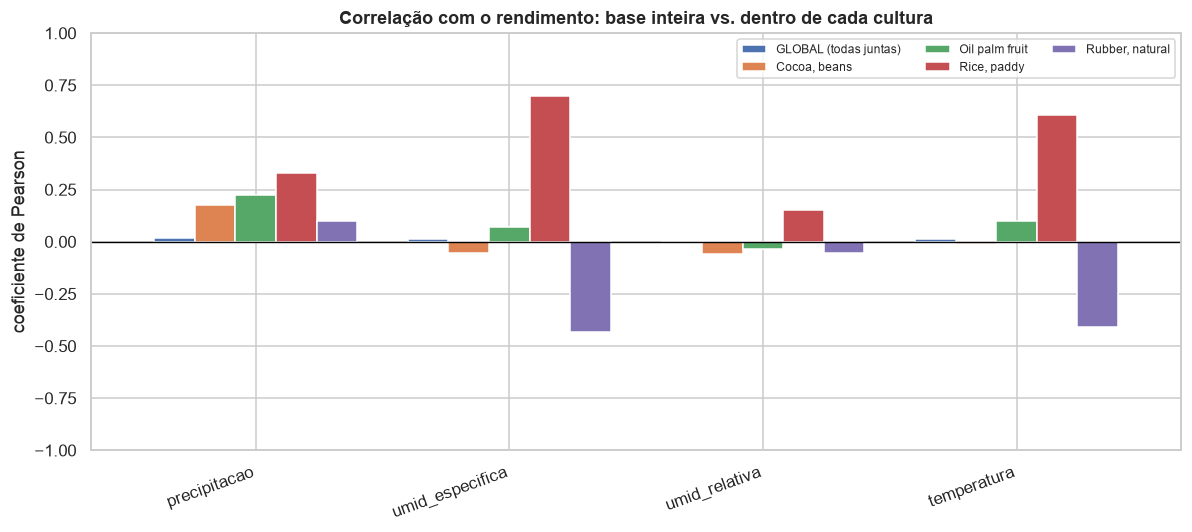

In [14]:
# Visualiza o contraste entre a leitura global e a leitura por cultura
plt.figure(figsize=(11, 5))
comparativo.plot(kind="bar", ax=plt.gca(), width=0.8, edgecolor="white")
plt.axhline(0, color="black", linewidth=0.9)
plt.title("Correlação com o rendimento: base inteira vs. dentro de cada cultura")
plt.ylabel("coeficiente de Pearson")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(title="", fontsize=8, ncol=3)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

**Achado — a correlação global não é apenas fraca: ela cancela efeitos reais.**

Na base inteira, as quatro variáveis climáticas têm correlação praticamente nula
com o rendimento — entre **0,00 e 0,02**. Lida isoladamente, essa matriz levaria
à conclusão de que o clima não tem relação alguma com a produtividade, o que
inviabilizaria o próprio projeto.

Ao recalcular dentro de cada cultura, o quadro se inverte:

| Variável | Global | Arroz | Borracha |
|---|---|---|---|
| umidade específica | 0,01 | **+0,70** | **−0,43** |
| temperatura | 0,01 | **+0,61** | **−0,41** |

Os efeitos existem e são fortes — mas têm **sinais opostos entre culturas**. Mais
umidade específica e mais calor beneficiam o arroz e prejudicam a borracha. Ao
agregar as quatro culturas numa única correlação, esses efeitos contrários se
cancelam e o resultado converge para zero.

Este é um caso de **paradoxo de Simpson**: a associação observada no agregado
desaparece — ou se inverte — quando os dados são estratificados pelo grupo
correto. A `cultura` é a variável de confusão que dirige simultaneamente o clima
observado e o patamar de rendimento.

**Duas consequências diretas para a seção 3:**

1. `cultura` precisa entrar como preditor. Sem ela, o modelo enxergaria
   correlação zero e não teria o que aprender.
2. Não basta incluí-la como deslocamento de nível (*intercepto*). Como a
   **inclinação** da relação clima→rendimento muda de sinal entre culturas, é
   preciso capturar a **interação** entre cultura e clima. Modelos lineares só
   fazem isso com termos de interação explícitos; modelos baseados em árvore
   capturam interações por construção. **Hipótese a testar na seção 3: os modelos
   de árvore devem superar os lineares nesta base.**

### 1.8 Relação entre clima e rendimento, cultura a cultura


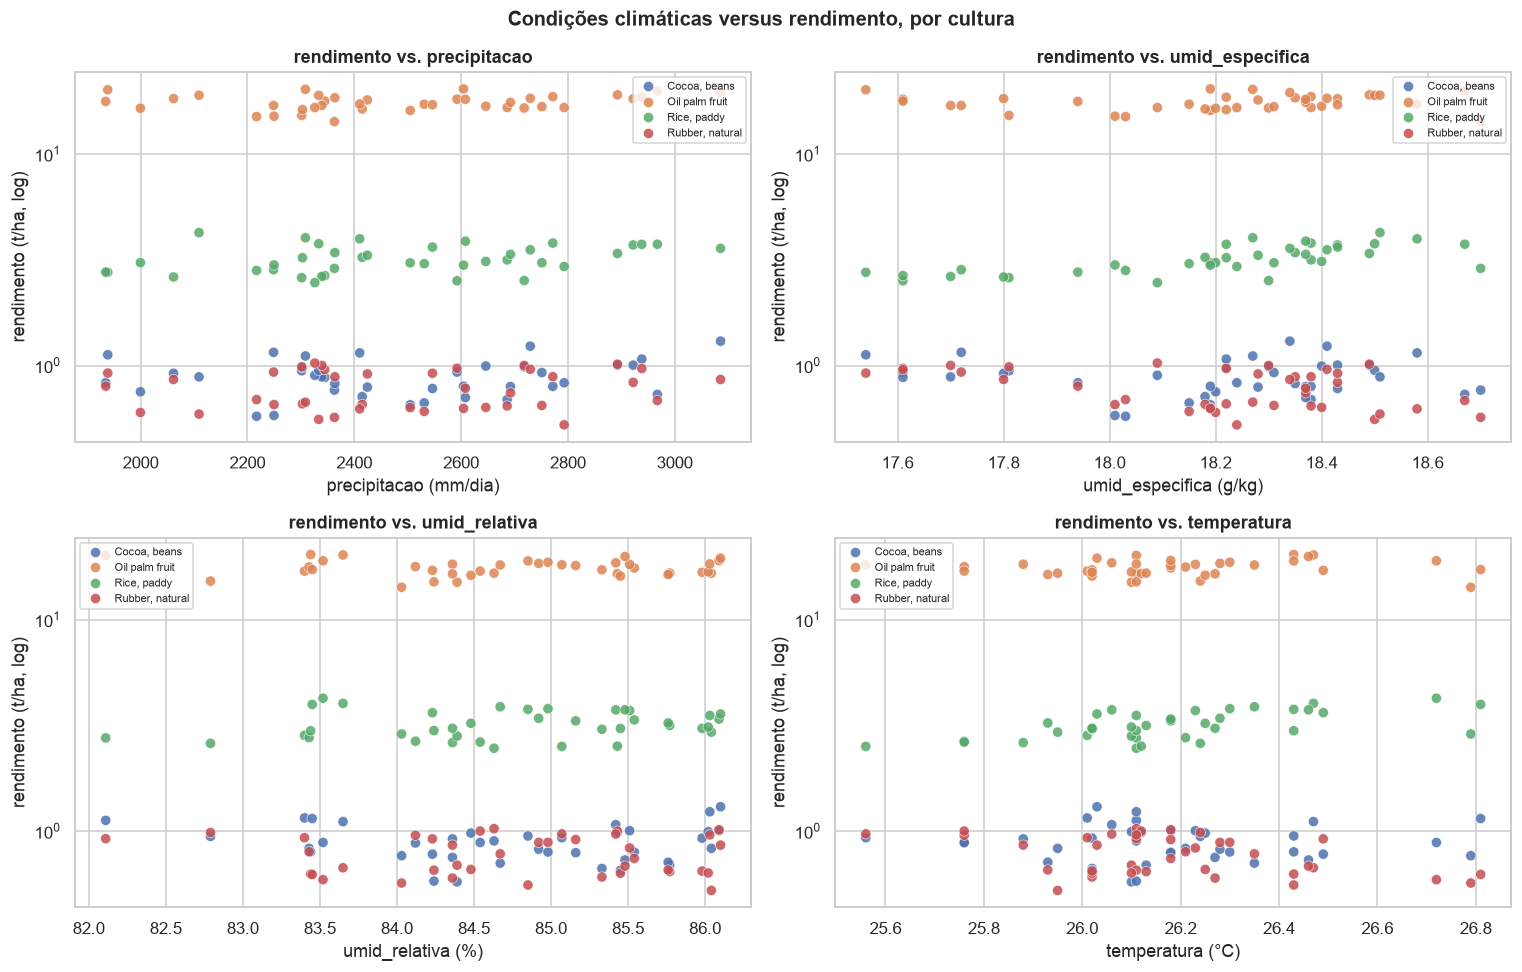

In [15]:
# Dispersao de cada variavel climatica contra o rendimento, colorida por cultura.
# A separacao visual por cor evidencia que cada cultura ocupa uma regiao propria.
fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

for ax, variavel in zip(eixos.ravel(), VARIAVEIS_CLIMA):
    sns.scatterplot(data=df, x=variavel, y=ALVO, hue="cultura", ax=ax,
                    s=45, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_yscale("log")  # escala log: sem ela, dende achata as demais culturas
    ax.set_title(f"rendimento vs. {variavel}")
    ax.set_xlabel(f"{variavel} ({UNIDADES[variavel]})")
    ax.set_ylabel("rendimento (t/ha, log)")
    ax.legend(fontsize=7, title="")

fig.suptitle("Condições climáticas versus rendimento, por cultura",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Achado.** Cada cultura forma uma **nuvem horizontal própria e bem delimitada**.
Dentro de cada nuvem, a dispersão ao longo do eixo climático é ampla, mas a
variação vertical (de rendimento) é comparativamente estreita.

Em outras palavras: **saber qual é a cultura já determina a maior parte do
rendimento esperado**; o clima explica a variação restante, dentro daquela faixa.
Essa é a estrutura que os modelos da seção 3 precisarão capturar — e é também o
motivo pelo qual esperamos que a clusterização da seção 2 reencontre as culturas.

---

### Síntese da análise exploratória

| # | Achado | Impacto no trabalho |
|---|---|---|
| 1 | 156 observações, zero nulos, zero duplicatas | Nenhum tratamento de qualidade necessário |
| 2 | 4 culturas com exatamente 39 observações cada | Base balanceada; série provavelmente anual, mas **sem a coluna de ano** |
| 3 | `Yield` está em hg/ha, não em t/ha | Conversão aplicada (÷ 10.000) e validada contra referências da FAO |
| 4 | Rendimento varia 22,5× entre culturas (mediana), com faixas disjuntas | Padronização obrigatória antes de clusterizar |
| 5 | Correlação global ≈ 0, mas intra-cultura chega a +0,70 e −0,43 (paradoxo de Simpson) | `cultura` é confundidora; os modelos precisam capturar a interação cultura×clima |
| 6 | Cada cultura ocupa uma nuvem própria no espaço climático | A cultura determina o patamar; o clima explica a variação interna |


<a id="bloco2"></a>
## 2. Clusterização e detecção de outliers

Esta seção usa **aprendizado não supervisionado** para responder duas perguntas
que a análise exploratória deixou em aberto:

1. Existem **agrupamentos naturais** de safras que compartilhem comportamento
   produtivo semelhante?
2. Há **cenários discrepantes** — condições ou resultados que fogem do padrão da
   base e que mereçam atenção do agrônomo?

### 2.1 Preparação: por que padronizar é obrigatório aqui

A seção 1.6 mostrou que o rendimento varia 22,5× entre culturas e que a
precipitação está na casa dos milhares, enquanto a temperatura gira em torno de
26. O K-Means minimiza distância euclidiana: sem padronização, a precipitação
sozinha — por ter a maior amplitude numérica — determinaria praticamente todos os
agrupamentos, e a temperatura seria ignorada.

O `StandardScaler` recentra cada variável em média zero e desvio padrão um,
colocando todas em pé de igualdade na conta da distância.


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Variaveis que entram na clusterizacao: as 4 climaticas + o rendimento
COLUNAS_CLUSTER = VARIAVEIS_CLIMA + [ALVO]

escalador = StandardScaler()
X_padronizado = escalador.fit_transform(df[COLUNAS_CLUSTER])

# Confere que a padronizacao funcionou: media ~0 e desvio ~1 em todas
pd.DataFrame(X_padronizado, columns=COLUNAS_CLUSTER).describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
precipitacao,0.00,1.00,-1.91,2.08
umid_especifica,-0.00,1.00,-2.26,1.70
umid_relativa,0.00,1.00,-2.65,1.37
temperatura,0.00,1.00,-2.40,2.41
rendimento,0.00,1.00,-0.73,2.10


### 2.2 Escolha do número de clusters

O `k` não pode ser escolhido no olho. Usamos dois critérios complementares:

- **Método do cotovelo** — mede a inércia (soma das distâncias quadradas ao
  centroide). Sempre cai quando `k` aumenta; procuramos o ponto em que a queda
  deixa de compensar a complexidade adicional.
- **Coeficiente de silhueta** — mede, para cada ponto, quão mais próximo ele está
  do próprio cluster do que do cluster vizinho mais próximo. Varia de −1 a 1;
  quanto maior, melhor a separação.


In [17]:
# Testa k de 2 a 10, registrando inercia e silhueta
faixa_k = range(2, 11)
resultados_k = []

for k in faixa_k:
    modelo_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    rotulos_k = modelo_k.fit_predict(X_padronizado)
    resultados_k.append({
        "k": k,
        "inercia": modelo_k.inertia_,
        "silhueta": silhouette_score(X_padronizado, rotulos_k),
    })

busca_k = pd.DataFrame(resultados_k).set_index("k")
busca_k.round(4)

,inercia,silhueta
k,,
2,535.97,0.32
3,383.13,0.33
4,303.33,0.36
5,259.03,0.37
6,223.14,0.36
7,189.92,0.39
8,166.17,0.39
9,153.45,0.38
10,135.93,0.36


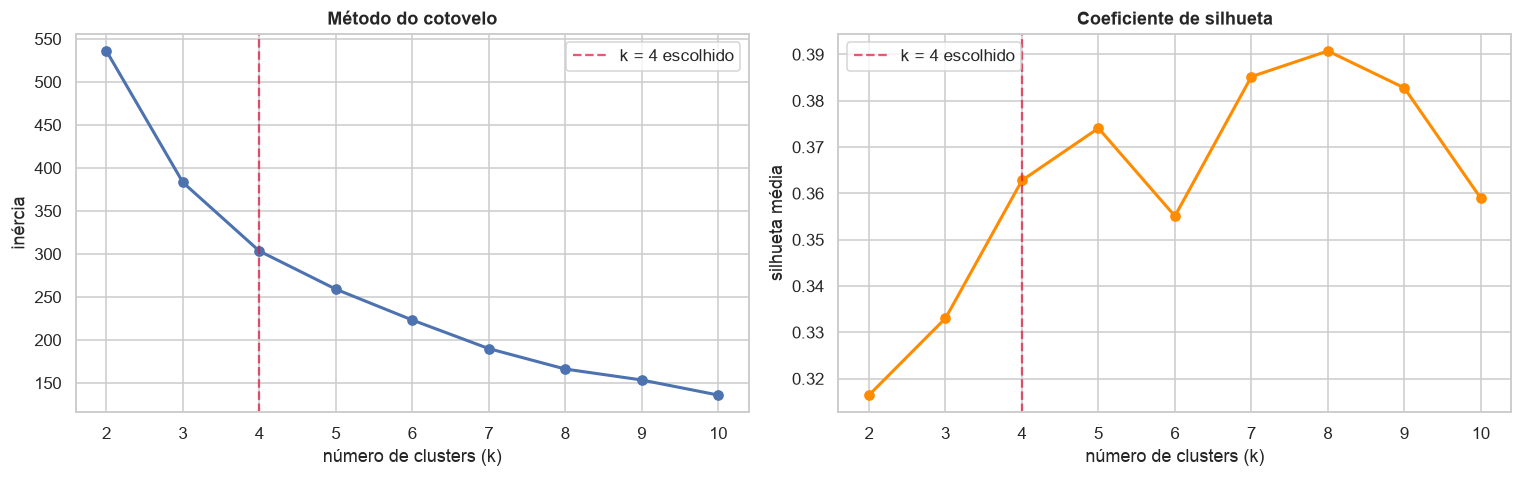

Maior silhueta: k=8 (0.3907)
Silhueta em k=4: 0.3628


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(busca_k.index, busca_k["inercia"], marker="o", linewidth=2)
ax1.set_title("Método do cotovelo")
ax1.set_xlabel("número de clusters (k)")
ax1.set_ylabel("inércia")
ax1.axvline(4, color="crimson", linestyle="--", alpha=0.7, label="k = 4 escolhido")
ax1.legend()

ax2.plot(busca_k.index, busca_k["silhueta"], marker="o", linewidth=2, color="darkorange")
ax2.set_title("Coeficiente de silhueta")
ax2.set_xlabel("número de clusters (k)")
ax2.set_ylabel("silhueta média")
ax2.axvline(4, color="crimson", linestyle="--", alpha=0.7, label="k = 4 escolhido")
ax2.legend()

plt.tight_layout()
plt.show()

melhor = busca_k["silhueta"].idxmax()
print(f"Maior silhueta: k={melhor} ({busca_k.loc[melhor, 'silhueta']:.4f})")
print(f"Silhueta em k=4: {busca_k.loc[4, 'silhueta']:.4f}")

**Achado — e uma escolha que precisa ser justificada com honestidade.**

Os dois critérios **não apontam para o mesmo `k`**:

- A curva de inércia cai de forma suave, **sem cotovelo pronunciado**. A maior
  quebra de inclinação ocorre entre `k=3` e `k=4`.
- A silhueta máxima está em **`k=8` (0,391)**, não em `k=4` (0,363).

Além disso, **todos os valores de silhueta são baixos** — entre 0,32 e 0,39.
Como referência, silhuetas abaixo de 0,50 indicam estrutura de agrupamento fraca:
os clusters existem, mas suas fronteiras são difusas. Essa é uma informação
relevante por si só, e não deve ser escondida atrás de uma escolha conveniente.

**Escolhemos `k=4`** por três razões:

1. A diferença de silhueta para `k=8` é de apenas 0,028 — irrelevante diante de
   valores tão baixos.
2. `k=8` produziria clusters com ~19 observações em média, pequenos demais para
   interpretação agronômica confiável numa base de 156 linhas.
3. Com `k=4` podemos **cruzar os clusters com as 4 culturas** e testar
   diretamente a hipótese levantada na seção 1: a de que os agrupamentos por
   condição vão simplesmente redescobrir as espécies cultivadas.

A escolha é de parcimônia e interpretabilidade, não de otimização da métrica —
e está declarada como tal.


In [19]:
# Ajusta o K-Means definitivo e anexa o rotulo de cluster ao dataframe
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_padronizado)

# Tabela cruzada: cada cluster contem quais culturas?
tabela_cruzada = pd.crosstab(df["cluster"], df["cultura"], margins=True,
                             margins_name="TOTAL")
tabela_cruzada

cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural",TOTAL
cluster,,,,,
0,0,26,0,0,26
1,11,3,11,11,36
2,17,0,17,17,51
3,11,10,11,11,43
TOTAL,39,39,39,39,156


**Achado — a hipótese estava errada, e o erro revela a estrutura da base.**

Esperávamos que os clusters reproduzissem as culturas. Não foi o que aconteceu:

- O **cluster 0** é puro: 26 observações, todas de dendê — e nenhuma outra cultura.
- Os **clusters 1, 2 e 3** são misturados, mas de um jeito muito peculiar. Cada um
  contém **exatamente o mesmo número** de cacau, arroz e borracha:
  11/11/11, 17/17/17 e 11/11/11.

Essa simetria perfeita não pode ser coincidência. Se os clusters fossem formados
por características das safras, não haveria razão para que cacau, arroz e borracha
caíssem em quantidades idênticas em cada grupo.

A explicação só pode ser uma: **as três culturas compartilham exatamente as mesmas
linhas de dados climáticos**. A célula seguinte testa isso formalmente.


In [20]:
# Testa se as 4 culturas compartilham identicamente as linhas climaticas.
# Separa cada cultura, reinicia o indice e compara os blocos entre si.
blocos_clima = {
    cultura: grupo[VARIAVEIS_CLIMA].reset_index(drop=True)
    for cultura, grupo in df.groupby("cultura", sort=False)
}
nomes_culturas = list(blocos_clima)
referencia = blocos_clima[nomes_culturas[0]]

print(f"Comparando o bloco climatico de '{nomes_culturas[0]}' com as demais:\n")
for nome in nomes_culturas[1:]:
    identico = referencia.equals(blocos_clima[nome])
    print(f"  vs {nome:18s} -> identico: {identico}")

# Quantas combinacoes climaticas distintas existem de fato na base?
combinacoes = df[VARIAVEIS_CLIMA].drop_duplicates()
repeticoes = df.groupby(VARIAVEIS_CLIMA).size().value_counts().to_dict()

print(f"\nLinhas na base:                        {len(df)}")
print(f"Combinacoes climaticas distintas:      {len(combinacoes)}")
print(f"Repeticoes por combinacao:             {repeticoes}")

Comparando o bloco climatico de 'Cocoa, beans' com as demais:

  vs Oil palm fruit     -> identico: True
  vs Rice, paddy        -> identico: True
  vs Rubber, natural    -> identico: True

Linhas na base:                        156
Combinacoes climaticas distintas:      39
Repeticoes por combinacao:             {4: 39}


### A base não tem 156 observações independentes. Tem 39.

O teste confirma: **as quatro culturas compartilham exatamente as mesmas 39 linhas
climáticas**, na mesma ordem. Existem apenas **39 combinações climáticas distintas**
na base, cada uma repetida **quatro vezes** — uma por cultura.

A estrutura real do arquivo é esta:

> 39 períodos de observação (provavelmente anos) de **uma única região**, e para
> cada período, o rendimento das 4 culturas cultivadas ali.

Isso reorganiza a interpretação de tudo o que veio antes:

**1. Explica a clusterização.** Os clusters 1, 2 e 3 não agrupam safras — agrupam
**períodos climáticos**. Como as três culturas de baixo rendimento (cacau, arroz,
borracha) têm valores próximos entre si na escala padronizada, elas viajam juntas
para o mesmo cluster do seu período. O dendê se destaca no cluster 0 porque seu
rendimento, muito superior, domina a distância euclidiana.

**2. Explica o paradoxo de Simpson da seção 1.7.** Como o clima é idêntico para as
quatro culturas, qualquer correlação calculada no agregado compara rendimentos de
espécies diferentes sob condições idênticas — o que mede diferença entre espécies,
não efeito climático.

**3. É a limitação mais séria do trabalho.** O tamanho amostral efetivo para
aprender a relação clima→rendimento é **39, não 156**. Com 4 variáveis preditoras,
isso significa cerca de 10 observações por variável — pouco para qualquer
afirmação estatística robusta.

**4. Tem consequência metodológica direta na seção 3.** Uma divisão treino/teste
aleatória colocaria o mesmo período climático nos dois conjuntos, mudando apenas a
cultura. O modelo veria no teste um vetor de clima que já viu no treino, o que
produz métrica **otimista**. Trataremos isso explicitamente na modelagem.


In [21]:
# Projeta os 5 eixos padronizados em 3 componentes principais
pca = PCA(n_components=3, random_state=RANDOM_STATE)
coordenadas = pca.fit_transform(X_padronizado)
variancia = pca.explained_variance_ratio_

# Loadings: quanto cada variavel original pesa em cada componente
cargas = pd.DataFrame(pca.components_.T, index=COLUNAS_CLUSTER,
                      columns=["CP1", "CP2", "CP3"]).round(3)
cargas

,CP1,CP2,CP3
precipitacao,0.60,-0.22,0.01
umid_especifica,0.55,0.45,-0.02
umid_relativa,0.57,-0.38,-0.01
temperatura,0.13,0.78,-0.01
rendimento,0.02,0.02,1.00


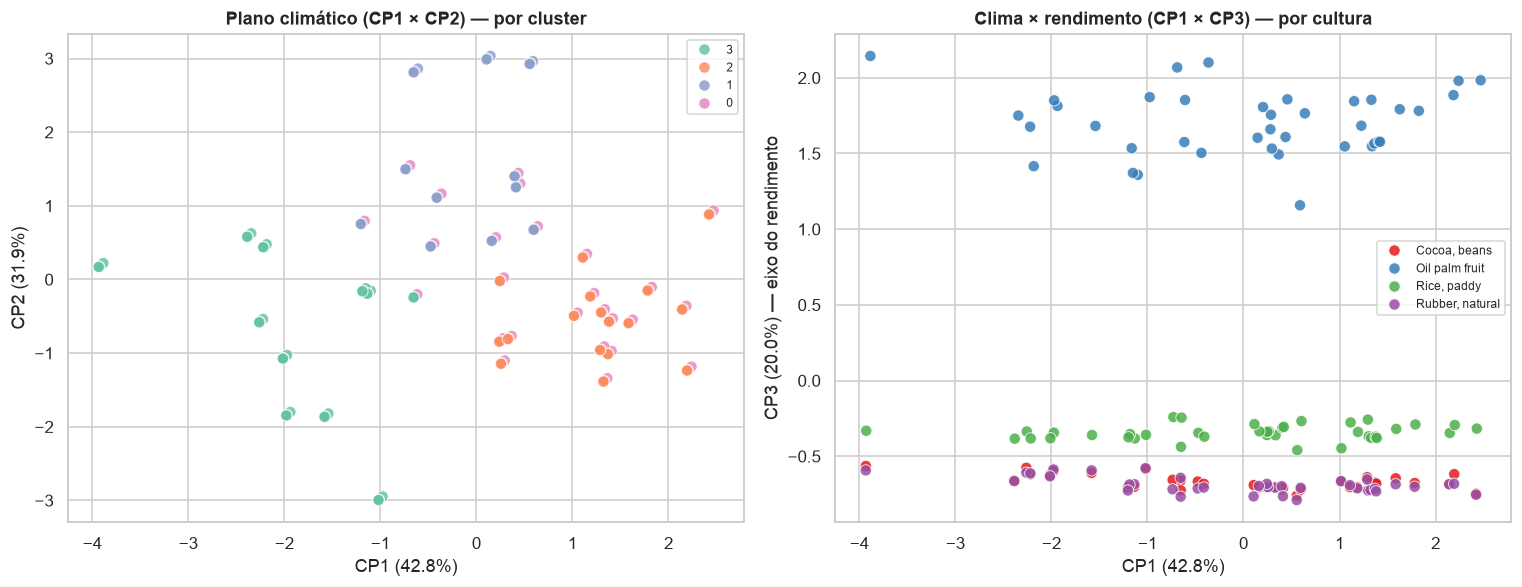

Variancia acumulada (CP1+CP2): 74.8%
Amplitude media entre as 4 culturas do MESMO periodo (CP1, CP2): 0.042, 0.047
Amplitude total da nuvem                       (CP1, CP2): 6.402, 6.030


In [22]:
df_pca = pd.DataFrame(coordenadas, columns=["CP1", "CP2", "CP3"])
df_pca["cluster"] = df["cluster"].astype(str)
df_pca["cultura"] = df["cultura"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# CP1 x CP2 - plano construido quase exclusivamente pelas variaveis climaticas
sns.scatterplot(data=df_pca, x="CP1", y="CP2", hue="cluster", ax=ax1,
                s=55, alpha=0.85, edgecolor="white", palette="Set2")
ax1.set_title("Plano climático (CP1 × CP2) — por cluster")
ax1.set_xlabel(f"CP1 ({variancia[0]:.1%})")
ax1.set_ylabel(f"CP2 ({variancia[1]:.1%})")

# CP1 x CP3 - CP3 carrega apenas o rendimento, separando as culturas
sns.scatterplot(data=df_pca, x="CP1", y="CP3", hue="cultura", ax=ax2,
                s=55, alpha=0.85, edgecolor="white", palette="Set1")
ax2.set_title("Clima × rendimento (CP1 × CP3) — por cultura")
ax2.set_xlabel(f"CP1 ({variancia[0]:.1%})")
ax2.set_ylabel(f"CP3 ({variancia[2]:.1%}) — eixo do rendimento")

for ax in (ax1, ax2):
    ax.legend(fontsize=8, title="")

plt.tight_layout()
plt.show()

# Quantifica a sobreposicao: quao distantes ficam as 4 culturas de um MESMO periodo?
periodo_temp = df.groupby("cultura").cumcount()
amplitudes = np.array([
    np.ptp(coordenadas[periodo_temp == t][:, :2], axis=0) for t in range(39)
])
print(f"Variancia acumulada (CP1+CP2): {variancia[:2].sum():.1%}")
print(f"Amplitude media entre as 4 culturas do MESMO periodo (CP1, CP2): "
      f"{amplitudes[:, 0].mean():.3f}, {amplitudes[:, 1].mean():.3f}")
print(f"Amplitude total da nuvem                       (CP1, CP2): "
      f"{np.ptp(coordenadas[:, 0]):.3f}, {np.ptp(coordenadas[:, 1]):.3f}")

In [23]:
# Perfil medio de cada cluster, na escala original das variaveis
perfil = df.groupby("cluster")[COLUNAS_CLUSTER].mean().round(2)
perfil["n"] = df["cluster"].value_counts().sort_index()
# Nao usar "cultura predominante": nos clusters 1, 2 e 3 ha empate exato entre
# tres culturas, e qualquer criterio de maioria escolheria uma delas arbitrariamente.
perfil["culturas presentes"] = df.groupby("cluster")["cultura"].nunique()
perfil["cluster puro?"] = np.where(perfil["culturas presentes"] == 1, "sim", "nao")
perfil

,precipitacao,umid_especifica,umid_relativa,temperatura,rendimento,n,culturas presentes,cluster puro?
cluster,,,,,,,,
0,"2,610.11",18.32,85.20,26.20,17.83,26,1,sim
1,"2,353.61",18.41,84.11,26.51,2.97,36,4,nao
2,"2,733.52",18.34,85.65,26.12,1.66,51,3,nao
3,"2,230.03",17.80,83.90,25.98,5.13,43,4,nao


**Interpretação dos clusters.**

| Cluster | n | Perfil |
|---|---|---|
| **0** | 26 | Exclusivamente dendê, rendimento médio de 17,8 t/ha. Separado pelo patamar produtivo, não pelo clima |
| **1** | 36 | Períodos mais **secos e quentes** (2.354 mm/dia, 26,5 °C). Rendimento médio 2,97 t/ha |
| **2** | 51 | Períodos mais **úmidos e amenos** (2.734 mm/dia, 26,1 °C). Rendimento médio 1,66 t/ha |
| **3** | 43 | Períodos de **menor precipitação** (2.230 mm/dia). Rendimento médio 5,13 t/ha, elevado pela presença de 10 observações de dendê |

Os clusters 1, 2 e 3 descrevem **regimes climáticos**, não tipos de safra. A
diferença de precipitação média entre o cluster 2 (mais úmido) e o cluster 3
(mais seco) é de cerca de 500 mm/dia — uma separação climática real e
interpretável.

**A PCA separou o problema em dois espaços independentes.**

A tabela de *loadings* mostra algo notável. Os dois primeiros componentes são
construídos **quase exclusivamente pelas variáveis climáticas** — o rendimento
pesa 0,017 em CP1 e 0,020 em CP2, praticamente zero. Já o **CP3 carrega o
rendimento com peso 1,000** e nada mais.

Ou seja: o plano CP1×CP2 é o **espaço climático puro** (74,8% da variância), e o
CP3 é o **eixo do rendimento** (20,0%). Eles são ortogonais por construção, e essa
separação limpa só é possível porque o clima e o rendimento variam de forma
independente nesta base — exatamente o que se espera quando o clima é replicado
identicamente entre as culturas.

Isso se confirma nos números: no plano climático, as quatro culturas de um mesmo
período ficam a uma distância média de **0,04**, contra uma amplitude total da
nuvem de **6,4**. As quatro culturas estão a menos de **0,7% da largura da nuvem**
umas das outras — no espaço climático, elas são literalmente o mesmo ponto. É por
isso que o gráfico da esquerda mostra apenas 39 posições distintas, cada uma com
quatro marcadores sobrepostos.

O gráfico da direita torna a estrutura visível: ao trocar o eixo vertical para
CP3, o dendê salta para o topo, isolado; o arroz forma uma faixa intermediária; e
cacau e borracha, cujos rendimentos são próximos (0,52 a 1,31 t/ha), praticamente
se fundem na base do gráfico. Cada posição horizontal continua sendo um período
climático — o eixo CP1 não mudou.

**Colinearidade.** O quinto componente explica 0,01% da variância, sinal de
redundância entre as variáveis climáticas: umidade específica e temperatura têm
correlação de 0,70, e precipitação e umidade relativa, 0,75. Isso é esperado
fisicamente — a capacidade do ar de reter vapor depende da temperatura — e
justifica testar modelos lineares **regularizados** na seção 3, já que
colinearidade infla a variância dos coeficientes de uma regressão comum.

### 2.3 Detecção de outliers

O enunciado pede a identificação de cenários discrepantes. Aplicamos **três
critérios independentes** e comparamos os resultados: se os três convergirem para
as mesmas observações, a evidência é forte; se divergirem, cada um está medindo
um tipo diferente de anomalia.


In [24]:
# CRITERIO A - Intervalo interquartil (IQR), calculado DENTRO de cada cultura.
# Calcular o IQR globalmente marcaria todo o dende como outlier, ja que sua
# faixa de rendimento nao se sobrepoe a das demais culturas.
outliers_iqr = {}

for variavel in COLUNAS_CLUSTER:
    indices = set()
    for _, grupo in df.groupby("cultura"):
        q1, q3 = grupo[variavel].quantile([0.25, 0.75])
        iqr = q3 - q1
        limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        fora = grupo[(grupo[variavel] < limite_inf) | (grupo[variavel] > limite_sup)]
        indices |= set(fora.index)
    outliers_iqr[variavel] = indices

resumo_iqr = pd.DataFrame({
    "variavel": list(outliers_iqr),
    "n outliers": [len(v) for v in outliers_iqr.values()],
})
resumo_iqr

,variavel,n outliers
0,precipitacao,0
1,umid_especifica,4
2,umid_relativa,4
3,temperatura,16
4,rendimento,0


In [25]:
# CRITERIO B - Escore z sobre os dados ja padronizados.
# Uma observacao e anomala se qualquer uma de suas variaveis se afasta mais
# de N desvios padrao da media.
escores_z = np.abs(X_padronizado).max(axis=1)

for limiar in (2.0, 2.5, 3.0):
    n = int((escores_z > limiar).sum())
    print(f"  |z| > {limiar}: {n:2d} observacoes")

df["escore_z_max"] = escores_z
outliers_z = set(df.index[escores_z > 2.5])
print(f"\nAdotando |z| > 2.5: {len(outliers_z)} observacoes")

  |z| > 2.0: 31 observacoes
  |z| > 2.5:  4 observacoes
  |z| > 3.0:  0 observacoes

Adotando |z| > 2.5: 4 observacoes


In [26]:
# CRITERIO C - Distancia euclidiana ao centroide do proprio cluster.
# Captura pontos que sao atipicos em relacao ao grupo ao qual foram atribuidos,
# mesmo que nenhuma variavel isolada seja extrema.
centroides = kmeans.cluster_centers_[kmeans.labels_]
distancias = np.linalg.norm(X_padronizado - centroides, axis=1)
limite_distancia = np.percentile(distancias, 95)

df["dist_centroide"] = distancias
outliers_dist = set(df.index[distancias > limite_distancia])

print(f"Distancia media ao centroide:  {distancias.mean():.2f}")
print(f"Distancia maxima:              {distancias.max():.2f}")
print(f"Limite (percentil 95):         {limite_distancia:.2f}")
print(f"Observacoes acima do limite:   {len(outliers_dist)}")

Distancia media ao centroide:  1.27
Distancia maxima:              3.14
Limite (percentil 95):         2.37
Observacoes acima do limite:   8


In [27]:
# Consolidacao: identifica o PERIODO climatico (0 a 38) de cada observacao,
# ja que as 4 culturas compartilham as mesmas 39 linhas de clima.
df["periodo"] = df.groupby("cultura").cumcount()

todos_iqr = set().union(*outliers_iqr.values())
marcados = {
    "IQR intra-cultura": todos_iqr,
    "escore z > 2.5": outliers_z,
    "distancia ao centroide > p95": outliers_dist,
}

consolidado = pd.DataFrame({
    nome: df["periodo"].isin(df.loc[list(idx), "periodo"]).groupby(df["periodo"]).first()
    for nome, idx in marcados.items()
})
consolidado["métodos que marcaram"] = consolidado.sum(axis=1)
periodos_suspeitos = consolidado[consolidado["métodos que marcaram"] > 0].sort_values(
    "métodos que marcaram", ascending=False)

# Anexa os valores climaticos de cada periodo suspeito
clima_periodos = df.drop_duplicates("periodo").set_index("periodo")[VARIAVEIS_CLIMA]
periodos_suspeitos.join(clima_periodos).round(2)

,IQR intra-cultura,escore z > 2.5,distancia ao centroide > p95,métodos que marcaram,precipitacao,umid_especifica,umid_relativa,temperatura
periodo,,,,,,,,
1,True,True,True,3,"1,938.42",17.54,82.11,26.11
3,True,False,True,2,"2,592.35",17.61,85.07,25.56
35,True,False,True,2,"2,410.13",18.58,83.45,26.81
38,True,False,True,2,"2,109.34",18.51,83.52,26.72
17,True,False,False,1,"2,362.80",18.70,84.03,26.79


**Achado — os outliers não são safras, são períodos climáticos.**

Os três critérios convergem para um punhado de **períodos**, não de safras
individuais. Isso é consequência direta da estrutura descoberta na seção 2.2:
como o clima é compartilhado pelas quatro culturas, um período atípico aparece
**quatro vezes** na base, uma por cultura.

Os achados por critério:

| Critério | O que encontrou |
|---|---|
| **IQR intra-cultura** | Zero outliers em **precipitação** e — o mais relevante — zero em **rendimento**, nas quatro culturas. As anomalias estão em temperatura (4 períodos) e umidade (1 período) |
| **Escore z** | Nenhuma observação ultrapassa 3 desvios padrão. Com o limiar relaxado para 2,5, apenas o período 1 é marcado |
| **Distância ao centroide** | 8 observações acima do percentil 95, concentradas em 4 períodos |

**O período 1 é marcado pelos três critérios** — é a anomalia mais consistente da
base: umidade específica de 17,54 g/kg e umidade relativa de 82,11%, ambas abaixo
do limite inferior do IQR. Os períodos 3, 35 e 38 são marcados por dois critérios,
todos por temperatura atípica.

**Decisão: mantemos todas as observações na base de treino.** A justificativa tem
três partes:

1. **Nenhum outlier de rendimento.** Nas quatro culturas, o critério IQR não
   encontrou uma única safra anormalmente boa ou ruim. As anomalias estão nas
   variáveis de entrada, não na saída — não há resultado suspeito a excluir.
2. **Anomalia climática é o sinal, não o ruído.** Um ano de calor ou seca atípica é
   exatamente o cenário em que a fazenda mais precisa de previsão confiável.
   Remover esses períodos treinaria um modelo que só funciona em anos normais.
3. **A base é pequena demais.** Descartar 4 períodos significaria perder 16 das
   156 linhas — mais de 10% — de uma amostra que já tem apenas 39 cenários
   independentes.

Registramos os períodos suspeitos como **contexto de interpretação**: se um dos
modelos da seção 3 errar sistematicamente nesses períodos, saberemos onde olhar.

---

### Síntese da clusterização

| # | Achado | Consequência |
|---|---|---|
| 1 | Nenhum `k` é claramente ótimo; silhueta entre 0,32 e 0,39 indica estrutura fraca | `k=4` escolhido por parcimônia e interpretabilidade, com a limitação declarada |
| 2 | Clusters não reproduzem as culturas: um cluster puro de dendê e três misturados em proporções idênticas | Levou à investigação que revelou a estrutura real da base |
| 3 | **As 4 culturas compartilham as mesmas 39 linhas climáticas** | Amostra efetiva é 39, não 156; exige cuidado na divisão treino/teste |
| 4 | Clusters 1, 2 e 3 separam regimes climáticos (seco/quente, úmido/ameno, menor precipitação) | Há tendência climática real a explorar, mesmo sem a coluna de ano |
| 5 | Colinearidade entre as climáticas (até 0,75) | Justifica testar modelos lineares regularizados na seção 3 |
| 6 | Zero outliers de rendimento; anomalias só no clima, em 4 períodos | Base mantida íntegra; períodos registrados para análise de resíduos |
